In [2]:
import os 
import tensorflow as tf
import numpy as np
import pandas as pd 
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt 
from pathlib import Path
from PIL import Image

2026-08-13 23:58:44.176295: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 23:58:44.332552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-13 23:58:44.332615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-13 23:58:44.358054: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-13 23:58:44.416497: I tensorflow/core/platform/cpu_feature_guar

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-08-13 23:58:45.109208: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
model = tf.keras.models.load_model(
    "../checkpoints/unet_best.keras"
)

2026-08-13 23:58:46.645927: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-13 23:58:46.755928: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-13 23:58:46.758224: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
datasetPath = Path("../dataset/data_wound_seg_256")

In [5]:
test_image_path= sorted(
    (datasetPath/"test_images").glob("*.png")
)

In [6]:
test_mask_path = sorted(
    (datasetPath/"test_masks").glob("*.png")
)

In [7]:
image = np.array(Image.open(test_image_path[0])).astype(np.float32)/255

In [8]:
mask = np.array(Image.open(test_mask_path[0]).convert("L")).astype(np.float32)/255

In [9]:
image, mask

(array([[[0.15294118, 0.13333334, 0.12156863],
         [0.14509805, 0.1254902 , 0.11372549],
         [0.15686275, 0.13725491, 0.1254902 ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.14901961, 0.12941177, 0.11764706],
         [0.15686275, 0.13725491, 0.1254902 ],
         [0.15294118, 0.13333334, 0.12156863],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.14901961, 0.12941177, 0.11764706],
         [0.16470589, 0.14509805, 0.13333334],
         [0.14901961, 0.12941177, 0.11764706],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        ...,
 
        [[0.03137255, 0.03137255, 0.03921569],
         [0.03137255, 0.03137255, 0.03921

In [10]:
pred = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

2026-08-13 23:59:26.523123: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


In [11]:
pred = pred[0]

In [12]:
pred

array([[[0.00013287],
        [0.00013484],
        [0.00021292],
        ...,
        [0.00053655],
        [0.00044429],
        [0.00044019]],

       [[0.00013325],
        [0.00013463],
        [0.00017501],
        ...,
        [0.00022232],
        [0.00020033],
        [0.00045482]],

       [[0.00016772],
        [0.00015087],
        [0.00013405],
        ...,
        [0.00022424],
        [0.00018205],
        [0.00042597]],

       ...,

       [[0.0006234 ],
        [0.00015879],
        [0.00014266],
        ...,
        [0.0002315 ],
        [0.00018195],
        [0.00043697]],

       [[0.0005546 ],
        [0.00018679],
        [0.00013258],
        ...,
        [0.00019196],
        [0.00016538],
        [0.00041347]],

       [[0.00045686],
        [0.0003481 ],
        [0.00035359],
        ...,
        [0.00040176],
        [0.00032028],
        [0.00039236]]], dtype=float32)

In [13]:
pred_mask = (pred > 0.5).astype(np.float32)

In [14]:
pred_mask

array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       ...,

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]], dtype=float32)

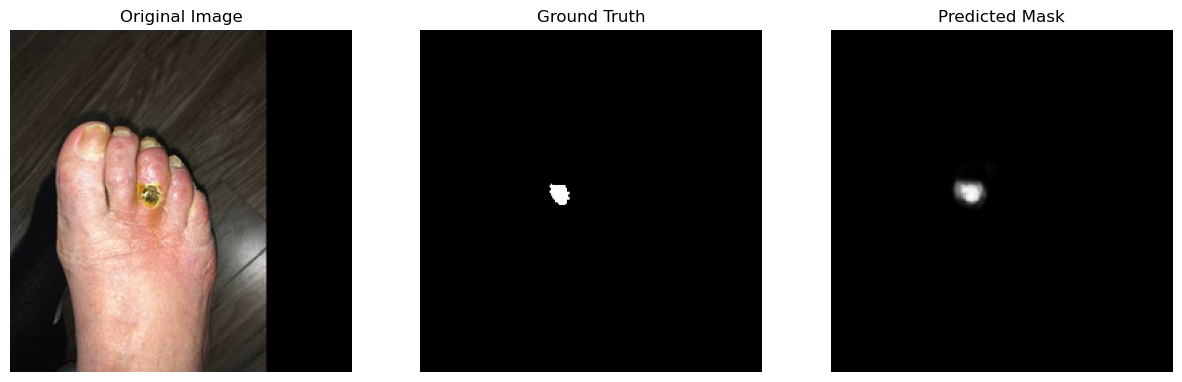

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred.squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [16]:
print("Prediction min:", pred.min())
print("Prediction max:", pred.max())
print("Prediction mean:", pred.mean())

Prediction min: 1.398048e-05
Prediction max: 0.95171756
Prediction mean: 0.0035022027


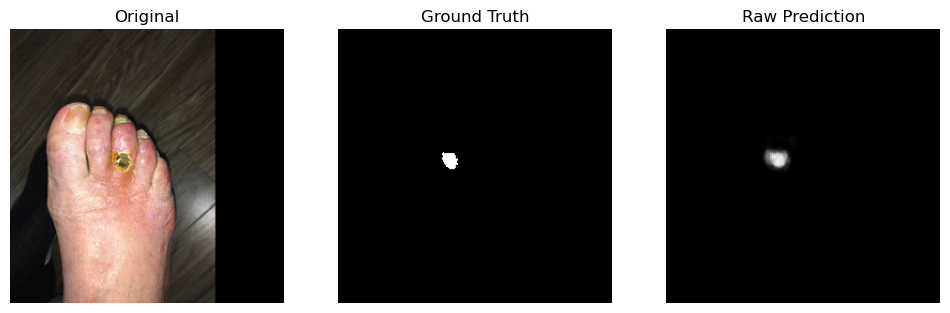

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Raw Prediction")
plt.axis("off")

plt.show()

In [18]:
predicted_mask = (pred > 0.5).astype(np.float32)

intersection = np.sum(mask * predicted_mask)

dice = (2 * intersection) / (
    np.sum(mask) + np.sum(predicted_mask) + 1e-7
)

iou = intersection / (
    np.sum(mask) + np.sum(predicted_mask) - intersection + 1e-7
)

print("Dice:", dice)
print("IoU:", iou)

Dice: 0.0
IoU: 0.0


In [19]:
print("mask shape:", mask.shape)
print("prediction shape:", pred.shape)

print("mask min/max:", mask.min(), mask.max())
print("prediction min/max:", pred.min(), pred.max())

predicted_mask = (pred > 0.5).astype(np.float32)

print("predicted mask shape:", predicted_mask.shape)
print("ground truth pixels:", np.sum(mask > 0.5))

mask shape: (256, 256)
prediction shape: (256, 256, 1)
mask min/max: 0.0 1.0
prediction min/max: 1.398048e-05 0.95171756
predicted mask shape: (256, 256, 1)
ground truth pixels: 171


In [20]:
pred_2d = pred.squeeze()

gt = mask > 0.5
pred_binary = pred_2d > 0.5

intersection = np.logical_and(gt, pred_binary).sum()
union = np.logical_or(gt, pred_binary).sum()

dice = (2 * intersection) / (
    gt.sum() + pred_binary.sum() + 1e-7
)

iou = intersection / (union + 1e-7)

print("GT pixels:", gt.sum())
print("Predicted pixels:", pred_binary.sum())
print("Intersection:", intersection)
print("Dice:", dice)
print("IoU:", iou)

GT pixels: 171
Predicted pixels: 179
Intersection: 151
Dice: 0.8628571426106122
IoU: 0.7587939694679428


In [21]:
def loadImageMask(imagePath, maskPath):
    image = tf.io.read_file(imagePath)
    image = tf.image.decode_png(image, channels = 3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask = tf.io.read_file(maskPath)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)
    image.set_shape([256, 256, 3])
    mask.set_shape([256, 256, 1])
    return image, mask


In [22]:
test_image_path = [str(p) for p in test_image_path]
test_mask_path = [str(p) for p in test_mask_path]

In [23]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_path, test_mask_path)
)
test_dataset = test_dataset.map(loadImageMask)
test_dataset = test_dataset.batch(8)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [24]:
for images, masks in test_dataset.take(1):
    print(images.shape)
    print(masks.shape)

(8, 256, 256, 3)
(8, 256, 256, 1)


In [25]:
dice_scores = []
iou_score = []
for images, masks in test_dataset:
    pred = model.predict(images, verbose=0)
    for i in range(images.shape[0]):
        gt = masks[i].numpy().squeeze() > 0.5
        pred_mask = pred[i].squeeze() > 0.5
        intersection = np.logical_and(gt, pred_mask).sum()
        union = np.logical_or(gt, pred_mask).sum()
        if gt.sum() == 0 and pred_mask.sum() == 0:
            dice = 1.0
            iou = 1.0
        else:
            dice = (2 * intersection) / (
                gt.sum() + pred_mask.sum() + 1e-7
            )
            iou = intersection / (union + 1e-7)

        dice_scores.append(dice)
        iou_score.append(iou)

2026-08-13 23:59:41.979667: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.70GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-13 23:59:42.835467: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.70GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


In [26]:
print("Test images evaluated:", len(dice_scores))
print("Mean Dice:", np.mean(dice_scores))
print("Mean IoU:", np.mean(iou_score))

Test images evaluated: 552
Mean Dice: 0.7393856040707478
Mean IoU: 0.6377360837518908


In [28]:
import json

with open("../checkpoints/training_history.json", "r") as f:
    history_data = json.load(f)

print(history_data.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [31]:
import json

with open("../checkpoints/training_history.json", "r") as f:
    history_data = json.load(f)

In [32]:
print(history_data.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


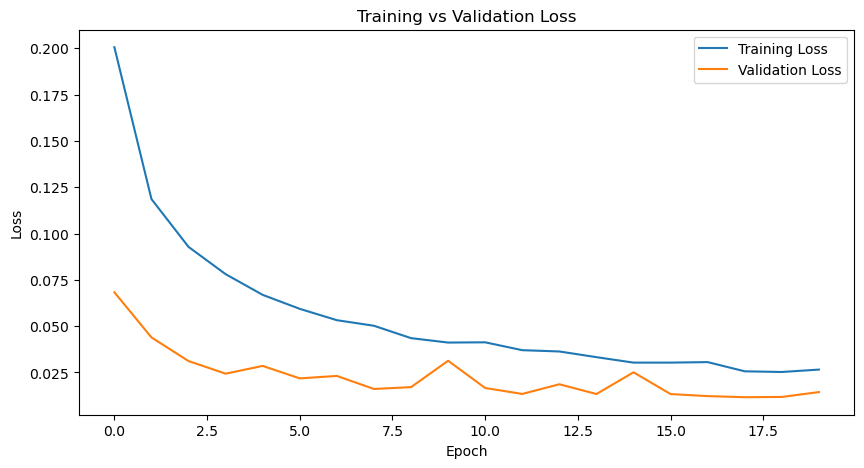

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

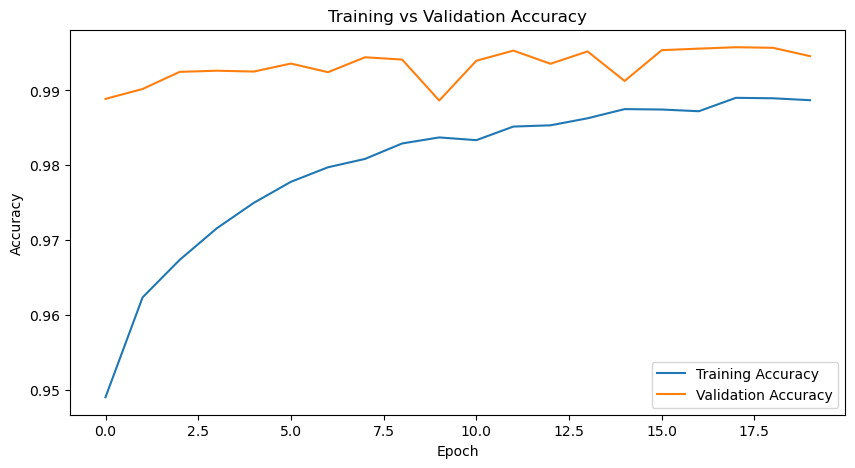

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()